In [164]:
import os

from torch.utils.data import Dataset, DataLoader
import torch
import torchinfo
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init

import matplotlib.pyplot as plt
import numpy as np

import albumentations as A

import SimpleITK
import SimpleITK as sitk

from collections import defaultdict
import time
import re
import random


### 1. Basic configuration


In [165]:
BASE_DIR = "database/"  # Name of de dataset folder

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():  # mac
    device = torch.device("mps")
else:
    device = torch.device("cpu")


print("Using device:", device)

sitk.ProcessObject_SetGlobalWarningDisplay(False)

Using device: mps


#### 1.1. General functions


In [166]:
def get_file_paths(directory):
    """
    Get all file paths in a directory and its subdirectories.
    """
    file_paths = []  # creates an empty list
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths


all_files = get_file_paths(BASE_DIR)

img_paths = [
    file
    for file in all_files
    if file.endswith(".nii.gz") and "_gt" not in file and "_4d" not in file
]
train_val_paths = [file for file in img_paths if "training" in file]


In [299]:
def plot_metrics(metrics):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(metrics["train_loss"], label="Train Loss")
    ax.plot(metrics["val_loss"], label="Val Loss")

    ax.set_title("Training and Validation Loss")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 2. FCN1


### 1.1 FCN1 - Dataset


In [167]:
class FCN1Dataset(Dataset):
    def __init__(self, filepath, transform=None):
        self.slices = []
        self.transform = transform

        for path in filepath:
            img = self._sitk_load(path, normalize=True)

            mask_path = path.replace(".nii.gz", "_gt.nii.gz")
            mask = self._sitk_load(mask_path, normalize=False)
            mask = (mask == 3).astype(np.float32)

            # regex to find info
            patient = path.split("/")[-2]
            frame = int(re.search(r"frame(\d+)", path).group(1))

            for i in range(img.shape[0]):
                self.slices.append(
                    {
                        "image": img[i],
                        "mask": mask[i],
                        "patient": patient,
                        "frame": frame,
                        "slice_idx": i,
                    }
                )

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        item = self.slices[idx]
        img = item["image"]
        mask = item["mask"]

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        img = torch.from_numpy(img).float()
        mask = torch.from_numpy(mask).float()

        img = img.unsqueeze(0)
        mask = mask.unsqueeze(0)

        metadata = {
            "patient": item["patient"],
            "frame": item["frame"],
            "slice_idx": item["slice_idx"],
        }

        return img, mask, metadata

    def _sitk_load(self, filepath, normalize=False) -> np.ndarray:
        """Loads an image using SimpleITK and returns the image and its metadata.
        Args:
            filepath: Path to the image.

        Returns:
            - ([N], H, W), Image array.

        """
        # Load image and save info
        image = SimpleITK.ReadImage(str(filepath))
        # Extract numpy array from the SimpleITK image object
        im_array = np.squeeze(SimpleITK.GetArrayFromImage(image))
        if normalize:
            im_array = im_array.astype(np.float32)
            im_array = (im_array - im_array.mean()) / (im_array.std() + 1e-8)

        return im_array


In [168]:
# p: probability of applying the transformations
train_transform = A.Compose(
    [
        A.Resize(
            height=256, width=256, p=1
        ),  # re-sized all the images to 256 × 256 pixels
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.1, 0.1), rotate=(-10, 10), p=1),
    ]
)

resized = A.Compose([A.Resize(height=256, width=256, p=1)])


In [169]:
# Choose 10 random patients from pattient 001 to patiento 100 for the validation set
random.seed(42)
patients = list(range(1, 101))  # patient001 - patient100
val_patients = random.sample(patients, 10)

train_paths = []
validation_paths = []

# Extracts the patient number from the file path and checks whether that patient belongs to the validation set.
for f in train_val_paths:
    patient = int(f.split("patient")[1][:3])
    if patient in val_patients:
        validation_paths.append(f)
    else:
        train_paths.append(f)

ds_train = FCN1Dataset(train_paths, train_transform)
ds_validation = FCN1Dataset(validation_paths, resized)


### 1.2. FCN1 - Explorate data


Training length:  1694
{'patient': 'patient012', 'frame': 13, 'slice_idx': 0}

Image

Shape: torch.Size([256, 256])


Mask

Shape: torch.Size([256, 256])


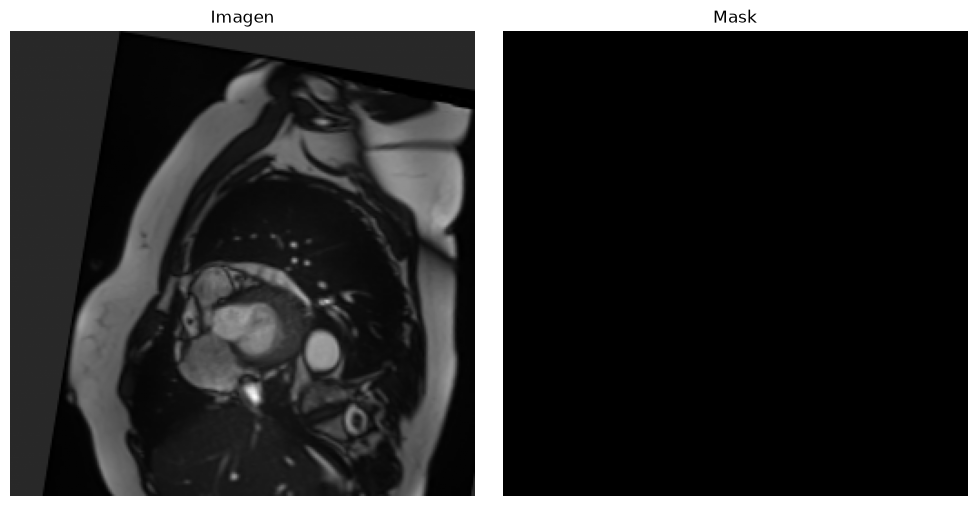

{'patient': 'patient012', 'frame': 13, 'slice_idx': 1}

Image

Shape: torch.Size([256, 256])


Mask

Shape: torch.Size([256, 256])


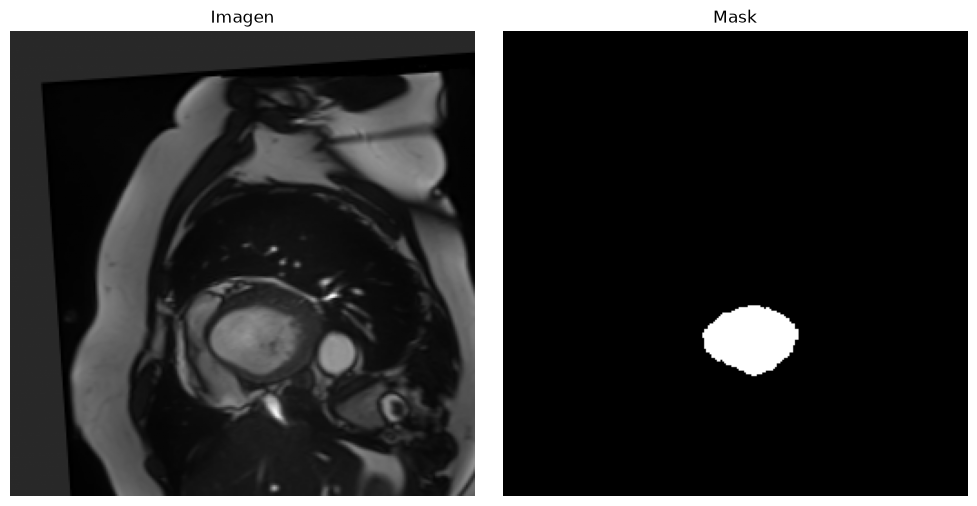

{'patient': 'patient012', 'frame': 13, 'slice_idx': 2}

Image

Shape: torch.Size([256, 256])


Mask

Shape: torch.Size([256, 256])


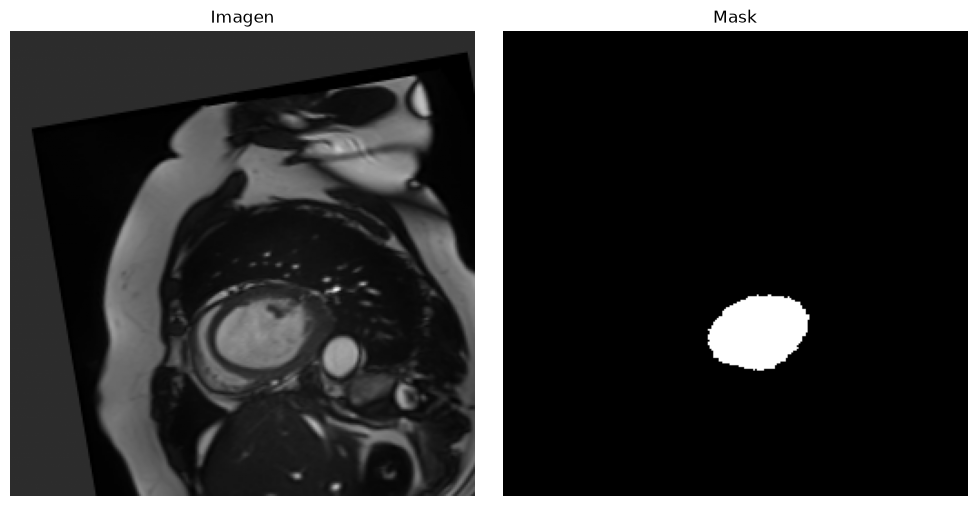

In [170]:
print("Training length: ", len(ds_train))

i = 0
for img, mask, _ in ds_train:
    print(_)
    # print(slice_idx)
    img = img.squeeze(0)
    mask = mask.squeeze(0)
    print("\nImage")
    print("\nShape:", img.shape)

    print("\n\nMask")
    print("\nShape:", mask.shape)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Imagen")
    axes[0].set_axis_off()

    axes[1].imshow(img, cmap="gray")
    axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Mask")
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()
    i = i + 1
    if i > 2:
        break


### 1.3. FCN1 - Architecture


In [171]:
class EncoderFCN1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        skip = x
        x = self.pool(x)
        return x, skip


class DecoderFCN1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Input: 512 - Output: 256
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        # Input: 256 *2 -> (because of skip connections)
        self.conv1 = nn.Conv2d(out_channels * 2, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, skip):
        x = self.upconv(x)
        # dim = 1: Concatenate along the channel dimension.
        x = torch.cat((x, skip), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x


class FCN1Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder1 = EncoderFCN1(1, 32)
        self.encoder2 = EncoderFCN1(32, 64)
        self.encoder3 = EncoderFCN1(64, 128)
        self.encoder4 = EncoderFCN1(128, 256)

        # Bottleneck
        self.bottleneck1 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn_b1 = nn.BatchNorm2d(512)
        # bottleneck2
        self.bottleneck2 = nn.Conv2d(512, 512, 3, padding=1)
        self.bn_b2 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()

        # Decoder
        self.decode1 = DecoderFCN1(512, 256)
        self.decode2 = DecoderFCN1(256, 128)
        self.decode3 = DecoderFCN1(128, 64)
        self.decode4 = DecoderFCN1(64, 32)

        self.final_conv = nn.Conv2d(32, 1, 3, padding=1)

        # init weights AFTER all layers exist
        self.apply(self.init_weights)

    def forward(self, x):
        x, s1 = self.encoder1(x)
        x, s2 = self.encoder2(x)
        x, s3 = self.encoder3(x)
        x, s4 = self.encoder4(x)

        x = self.bottleneck1(x)
        x = self.bn_b1(x)
        x = self.relu(x)
        x = self.bottleneck2(x)
        x = self.bn_b2(x)
        x = self.relu(x)

        x = self.decode1(x, s4)
        x = self.decode2(x, s3)
        x = self.decode3(x, s2)
        x = self.decode4(x, s1)

        x = self.final_conv(x)
        return x

    def init_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            init.kaiming_normal_(m.weight, nonlinearity="relu")

In [172]:
img_size = (256, 256)
batch_size = 8

torchinfo.summary(FCN1Net(), input_size=(batch_size, 1, img_size[0], img_size[1]))

Layer (type:depth-idx)                   Output Shape              Param #
FCN1Net                                  [8, 1, 256, 256]          --
├─EncoderFCN1: 1-1                       [8, 32, 128, 128]         --
│    └─Conv2d: 2-1                       [8, 32, 256, 256]         320
│    └─BatchNorm2d: 2-2                  [8, 32, 256, 256]         64
│    └─ReLU: 2-3                         [8, 32, 256, 256]         --
│    └─Conv2d: 2-4                       [8, 32, 256, 256]         9,248
│    └─BatchNorm2d: 2-5                  [8, 32, 256, 256]         64
│    └─ReLU: 2-6                         [8, 32, 256, 256]         --
│    └─MaxPool2d: 2-7                    [8, 32, 128, 128]         --
├─EncoderFCN1: 1-2                       [8, 64, 64, 64]           --
│    └─Conv2d: 2-8                       [8, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-9                  [8, 64, 128, 128]         128
│    └─ReLU: 2-10                        [8, 64, 128, 128]         --
│    └

### 1.3. FCN1 - Training


In [173]:
BATCHSIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.001


def train_model(
    model,
    train_loader,
    validation_loader,
    criterion=nn.BCEWithLogitsLoss(),
    epochs=EPOCHS,
):
    """
    Train the model on the training set and validate it on the validation set.

    Return the training and validation metrics.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    metrics = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(epochs):
        start = time.time()
        losses = 0
        model.train()
        for img, mask, _ in train_loader:
            img = img.to(device)
            mask = mask.to(device)

            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)
            loss.backward()
            optimizer.step()
            losses += loss.item()

        metrics["train_loss"].append(losses / len(train_loader))
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for img, mask, _ in validation_loader:
                img = img.to(device)
                mask = mask.to(device)

                output = model(img)
                val_loss += criterion(output, mask).item()
            metrics["val_loss"].append(val_loss / len(validation_loader))

        print(
            f"Epoch {epoch + 1} in {time.time() - start:.2f} s, Train Loss: {metrics['train_loss'][-1]:.5f}, Val Loss: {metrics['val_loss'][-1]:.5f}"
        )

    return metrics


model = FCN1Net().to(device)
criterion = nn.BCEWithLogitsLoss()
generator = torch.Generator(device="cuda") if device.type == "cuda" else None

dataloader_args = {
    "batch_size": BATCHSIZE,
    "generator": generator,
}

# shuffle = True  the data is randomly shuffled before each epoch.
dl_train = DataLoader(ds_train, **dataloader_args, shuffle=True)
dl_val = DataLoader(ds_validation, **dataloader_args, shuffle=False)

metrics = train_model(model, dl_train, dl_val, criterion=criterion, epochs=EPOCHS)
print("Training is done")

Epoch 1 in 37.35 s, Train Loss: 0.05676, Val Loss: 0.01823
Epoch 2 in 36.56 s, Train Loss: 0.00874, Val Loss: 0.01306
Epoch 3 in 36.53 s, Train Loss: 0.00609, Val Loss: 0.00597
Epoch 4 in 36.51 s, Train Loss: 0.00498, Val Loss: 0.00640
Epoch 5 in 35.73 s, Train Loss: 0.00437, Val Loss: 0.00943
Epoch 6 in 35.43 s, Train Loss: 0.00388, Val Loss: 0.00513
Epoch 7 in 35.30 s, Train Loss: 0.00368, Val Loss: 0.00847
Epoch 8 in 35.28 s, Train Loss: 0.00458, Val Loss: 0.00417
Epoch 9 in 35.26 s, Train Loss: 0.00334, Val Loss: 0.00449
Epoch 10 in 35.72 s, Train Loss: 0.00314, Val Loss: 0.00371
Epoch 11 in 36.47 s, Train Loss: 0.00319, Val Loss: 0.00380
Epoch 12 in 36.27 s, Train Loss: 0.00304, Val Loss: 0.00337
Epoch 13 in 36.09 s, Train Loss: 0.00274, Val Loss: 0.00409
Epoch 14 in 36.09 s, Train Loss: 0.00302, Val Loss: 0.00536
Epoch 15 in 36.08 s, Train Loss: 0.00293, Val Loss: 0.00475
Epoch 16 in 36.08 s, Train Loss: 0.00290, Val Loss: 0.00380
Epoch 17 in 36.10 s, Train Loss: 0.00321, Val Los

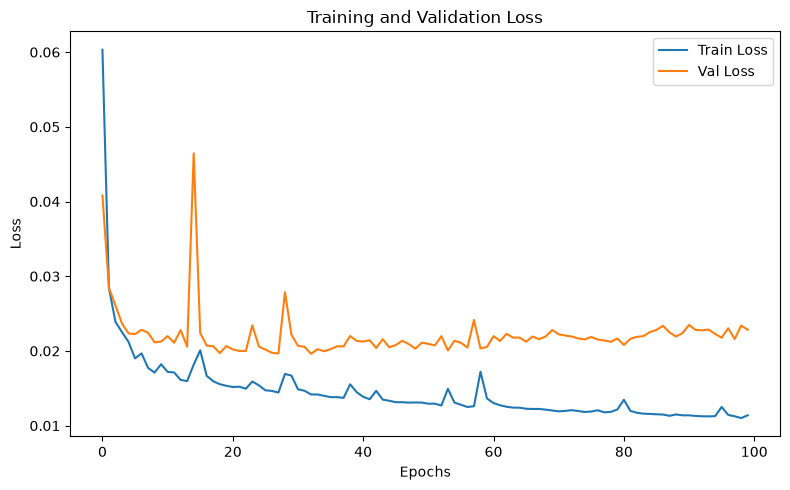

In [302]:
plot_metrics(metrics)

## 3. FCN2


### 3.1. Functions to get centroid


In [174]:
def calculate_centroid(mask_np):
    """
    Calculates the centroid (y, x) of a binary mask.
    Returns (y_mean, x_mean) or None if the mask is empty.
    """
    y_indices, x_indices = np.where(mask_np > 0)
    if len(y_indices) == 0:
        return None
    return (np.mean(y_indices), np.mean(x_indices))


def fill_missing_centroids(data):
    groups = defaultdict(list)
    for item in data:
        # Usar tipos nativos para asegurar que el hash agrupe correctamente
        group_key = (str(item["patient"]), str(item["frame"]))
        groups[group_key].append(item)

    result = []

    for group_key, group in groups.items():
        group.sort(key=lambda x: x["slice_idx"])

        # Forward Fill para pred_centroid y gt_centroid
        for i in range(1, len(group)):
            if group[i]["pred_centroid"] is None:
                group[i]["pred_centroid"] = group[i - 1]["pred_centroid"]
            if group[i]["gt_centroid"] is None:
                group[i]["gt_centroid"] = group[i - 1]["gt_centroid"]

        # Backward Fill para pred_centroid y gt_centroid
        for i in range(len(group) - 2, -1, -1):
            if group[i]["pred_centroid"] is None:
                group[i]["pred_centroid"] = group[i + 1]["pred_centroid"]
            if group[i]["gt_centroid"] is None:
                group[i]["gt_centroid"] = group[i + 1]["gt_centroid"]

        result.extend(group)
    return result


def calculate_centroid_metrics(data):
    errors = []

    for item in data:
        pred = item["pred_centroid"]
        gt = item["gt_centroid"]

        if pred is not None and gt is not None:
            pred_arr = np.array(pred)
            gt_arr = np.array(gt)

            # np.linalg.norm is a function in the Python NumPy library that calculates the norm of a vector or matrix.
            error = np.linalg.norm(pred_arr - gt_arr)
            errors.append(error)

    if not errors:
        return None, None, None, None

    mean_error = np.mean(errors)
    min_error = np.min(errors)
    max_error = np.max(errors)
    std_error = np.std(errors)

    return mean_error, min_error, max_error, std_error


### 3.1 FCN2 - Dataset class


In [ ]:
ROI_SIZE = 128


def crop_center(img, x_center, y_center, size=ROI_SIZE):
    """
    Crop a fixed-size square around a given center.

    Args:
        img: input image (256x256)
        x_center, y_center: center coordinates of ROI
        size: output crop size (default 128x128)

    Returns:
        Cropped image of size x size
    """
    _, height, width = img.shape
    half = size // 2

    x_start = int(np.clip(np.round(x_center - half), 0, width - size))
    y_start = int(np.clip(np.round(y_center - half), 0, height - size))

    return img[:, y_start : y_start + size, x_start : x_start + size]


In [289]:
NOISE = 10


class FCN2Dataset(Dataset):
    def __init__(self, filepath, transform=None, mode="train"):
        self.slices = []
        self.transform = transform
        self.mode = mode
        self.noise = NOISE

        for path in filepath:
            img = self._sitk_load(path, normalize=True)

            mask_path = path.replace(".nii.gz", "_gt.nii.gz")
            mask = self._sitk_load(mask_path)

            for i in range(img.shape[0]):
                self.slices.append({"image": img[i], "mask": mask[i]})

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        item = self.slices[idx]
        img = item["image"]
        mask = item["mask"]

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        channel_two = (mask == 2).astype(np.float32)  # myocardium
        channel_three = (mask == 3).astype(np.float32)  # cavity
        new_mask = np.stack([channel_two, channel_three], axis=0)

        new_mask = torch.from_numpy(new_mask).float()
        img = torch.from_numpy(img).float().unsqueeze(0)

        # Testing mode: Return full image
        # FCN1 will handle the cropping dynamically in the evaluation loop.
        if self.mode == "test":
            return img, new_mask

        # Calculate Ground Truth Centroid
        mask_3 = (mask == 3).astype(np.float32)
        gt_centroid = calculate_centroid(mask_3)

        # Training: add noise to the ground-truth centroid and crop the image accordingly
        if gt_centroid is not None:
            y1, x1 = gt_centroid

            if self.mode == "train":
                x0, y0 = (
                    random.randint(-self.noise, self.noise),
                    random.randint(-self.noise, self.noise),
                )  # noise

            elif self.mode == "val":
                x0, y0 = (0, 0)
            noise_centroid = (float(x0 + x1), float(y0 + y1))
        else:
            noise_centroid = (64.0, 64.0)

        crop_img = crop_center(
            img,
            x_center=noise_centroid[0],
            y_center=noise_centroid[1],
            size=ROI_SIZE,
        )
        crop_mask = crop_center(
            new_mask,
            x_center=noise_centroid[0],
            y_center=noise_centroid[1],
            size=ROI_SIZE,
        )
        return crop_img, crop_mask

    def _sitk_load(self, filepath, normalize=False) -> np.ndarray:
        """Loads an image using SimpleITK and returns the image and its metadata.
        Args:
            filepath: Path to the image.

        Returns:
            - ([N], H, W), Image array.

        """
        # Load image and save info
        image = SimpleITK.ReadImage(str(filepath))
        # Extract numpy array from the SimpleITK image object
        im_array = np.squeeze(SimpleITK.GetArrayFromImage(image))
        if normalize:
            im_array = im_array.astype(np.float32)
            im_array = (im_array - im_array.mean()) / (im_array.std() + 1e-8)

        return im_array


In [270]:
# Choose 10 random patients from pattient 001 to patiento 100 for the validation set
random.seed(42)
patients = list(range(1, 101))  # patient001 - patient100
val_patients = random.sample(patients, 10)

train_paths = []
validation_paths = []

# Extracts the patient number from the file path and checks whether that patient belongs to the validation set.
for f in train_val_paths:
    patient = int(f.split("patient")[1][:3])
    if patient in val_patients:
        validation_paths.append(f)
    else:
        train_paths.append(f)

ds_train_fcn2 = FCN2Dataset(train_paths, train_transform, "train")
ds_validation_fcn2 = FCN2Dataset(validation_paths, resized, "val")

### 3.2. Data exploration


Training length: 1694


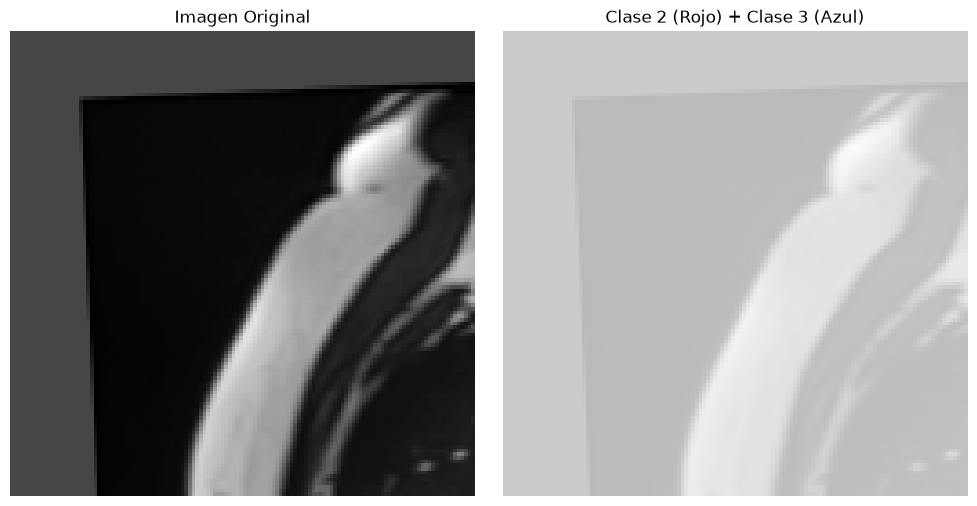

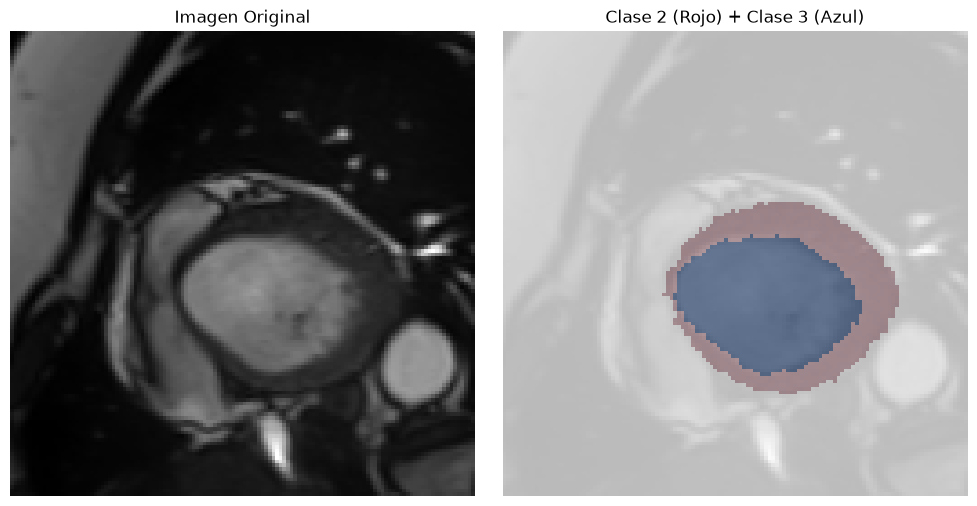

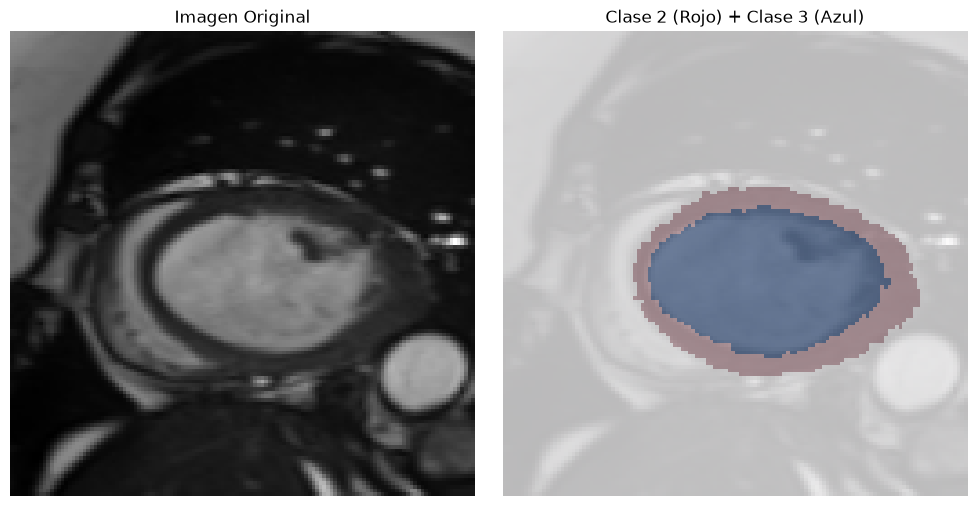

In [ ]:
print("Training length:", len(ds_train_fcn2))

i = 0
for img, mask in ds_train_fcn2:
    img_2d = img.squeeze(0).numpy()
    mask_clase_2 = mask[0].numpy()
    mask_clase_3 = mask[1].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Imagen original
    axes[0].imshow(img_2d, cmap="gray")
    axes[0].set_title("Imagen Original")
    axes[0].axis("off")

    # Ambas máscaras superpuestas
    axes[1].imshow(img_2d, cmap="gray")
    axes[1].imshow(mask_clase_2, cmap="Reds", alpha=0.5, vmin=0, vmax=1)
    axes[1].imshow(mask_clase_3, cmap="Blues", alpha=0.5, vmin=0, vmax=1)
    axes[1].set_title("Clase 2 (Rojo) + Clase 3 (Azul)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 3:
        break


### 3.3. FCN2 - Architecture


In [273]:
class DoubleEncoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

    def forward(self, x, skip=None):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        skip = x
        x = self.pool(x)
        return x, skip


class DecoderDouble(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv1 = nn.Conv2d(out_channels * 2, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat((x, skip), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x


class DecoderSingle(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv1 = nn.Conv2d(out_channels * 2, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat((x, skip), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        return x


class InceptionModule(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=1),
            nn.Conv2d(16, 24, kernel_size=3, padding=1),
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, 12, kernel_size=1),
            nn.Conv2d(12, 16, kernel_size=5, padding=2),
        )
        self.branch3 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, 8, kernel_size=1),
        )
        self.branch4 = nn.Conv2d(in_channels, 16, kernel_size=1)

    def forward(self, x):
        return torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1
        )


class FCN2Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Shared Contracting Path -  Encoder columnxrow
        self.encoder11 = DoubleEncoder(1, 16)
        self.encoder12 = DoubleEncoder(16, 32)
        self.encoder13 = DoubleEncoder(32, 64)
        self.encoder14 = DoubleEncoder(64, 128)

        # Bottleneck 4
        self.bottleneck1 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn_b1 = nn.BatchNorm2d(256)
        self.bottleneck2 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn_b2 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU()

        # --- Expanding Paths (Parallel, independent decoders) ---
        # All paths use DecoderDouble as per the diagram showing 2 convolutions per level

        # Path 4 (Up-sampling from 256 channels)
        self.p4_up1 = DecoderDouble(256, 128)
        self.p4_up2 = DecoderDouble(128, 64)
        self.p4_up3 = DecoderDouble(64, 32)
        self.p4_up4 = DecoderDouble(32, 16)

        # Path 3 (Up-sampling from 128 channels)
        self.p3_up1 = DecoderDouble(128, 64)
        self.p3_up2 = DecoderDouble(64, 32)
        self.p3_up3 = DecoderDouble(32, 16)

        # Path 2 (Up-sampling from 64 channels)
        self.p2_up1 = DecoderDouble(64, 32)
        self.p2_up2 = DecoderDouble(32, 16)

        # Path 1 (Up-sampling from 32 channels)
        self.p1_up1 = DecoderDouble(32, 16)

        # Inception Module and Final Projection
        # Concatenates 16 channels from each of the 4 paths = 64 input channels
        self.inception = InceptionModule(64)
        # Map to 2 classes (LV cavity and Myocardium)
        self.final_conv = nn.Conv2d(64, 2, 3, padding=1)
        self.sigmoid = nn.Sigmoid()

        # init weights AFTER all layers exist
        self.apply(self.init_weights)

    def forward(self, x):
        # Enconder + skips conections
        x_pool1, s1 = self.encoder11(x)
        x_pool2, s2 = self.encoder12(x_pool1)
        x_pool3, s3 = self.encoder13(x_pool2)
        x_pool4, s4 = self.encoder14(x_pool3)

        # Bottleneck 4
        bottleneck4 = self.bottleneck1(x_pool4)
        bottleneck4 = self.bn_b1(bottleneck4)
        bottleneck4 = self.relu(bottleneck4)
        bottleneck4 = self.bottleneck2(bottleneck4)
        bottleneck4 = self.bn_b2(bottleneck4)
        bottleneck4 = self.relu(bottleneck4)

        # 3. Independent Forward Propagation per Expanding Path
        # No paths are mixed until the final concatenation

        # Path 4
        d4 = self.p4_up1(bottleneck4, s4)
        d4 = self.p4_up2(d4, s3)
        d4 = self.p4_up3(d4, s2)
        d4_out = self.p4_up4(d4, s1)

        # Path 3
        d3 = self.p3_up1(s4, s3)
        d3 = self.p3_up2(d3, s2)
        d3_out = self.p3_up3(d3, s1)

        # Path 2
        d2 = self.p2_up1(s3, s2)
        d2_out = self.p2_up2(d2, s1)

        # Path 1
        d1_out = self.p1_up1(s2, s1)

        # 4. Final Concatenation, Inception processing, and Sigmoid probability map
        out = torch.cat((d4_out, d3_out, d2_out, d1_out), dim=1)
        out = self.inception(out)
        logits = self.final_conv(out)
        # prob_map = self.sigmoid(logits)

        return logits

    def init_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            init.kaiming_normal_(m.weight, nonlinearity="relu")


In [274]:
img_size = (128, 128)
batch_size = 8

torchinfo.summary(FCN2Net(), input_size=(batch_size, 1, img_size[0], img_size[1]))

Layer (type:depth-idx)                   Output Shape              Param #
FCN2Net                                  [8, 2, 128, 128]          --
├─DoubleEncoder: 1-1                     [8, 16, 64, 64]           --
│    └─Conv2d: 2-1                       [8, 16, 128, 128]         160
│    └─BatchNorm2d: 2-2                  [8, 16, 128, 128]         32
│    └─ReLU: 2-3                         [8, 16, 128, 128]         --
│    └─Conv2d: 2-4                       [8, 16, 128, 128]         2,320
│    └─BatchNorm2d: 2-5                  [8, 16, 128, 128]         32
│    └─ReLU: 2-6                         [8, 16, 128, 128]         --
│    └─MaxPool2d: 2-7                    [8, 16, 64, 64]           --
├─DoubleEncoder: 1-2                     [8, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [8, 32, 64, 64]           4,640
│    └─BatchNorm2d: 2-9                  [8, 32, 64, 64]           64
│    └─ReLU: 2-10                        [8, 32, 64, 64]           --
│    └─C

### 3.4. FCN2 - Training


In [ ]:
print("Training...")

BATCHSIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.001


def train_model_fcn2(
    model,
    train_loader,
    validation_loader,
    learning_rate=LEARNING_RATE,
    criterion=nn.BCEWithLogitsLoss(),
    epochs=EPOCHS,
):
    """
    Train the model on the training set and validate it on the validation set.

    Return the training and validation metrics.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    metrics = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(epochs):
        start = time.time()
        losses = 0
        model.train()
        for img, mask in train_loader:
            img = img.to(device).float()
            mask = mask.to(device).float()

            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)

            loss.backward()
            optimizer.step()
            losses += loss.item()

        metrics["train_loss"].append(losses / len(train_loader))
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for img, mask in validation_loader:
                img = img.to(device)
                mask = mask.to(device)

                output = model(img)
                val_loss += criterion(output, mask).item()

            metrics["val_loss"].append(val_loss / len(validation_loader))

        print(
            f"Epoch {epoch + 1} in {time.time() - start:.2f} s, Train Loss: {metrics['train_loss'][-1]:.5f}, Val Loss: {metrics['val_loss'][-1]:.5f}"
        )

    return metrics


model = FCN2Net().to(device)
# criterion = FCN2CombinedLoss()
criterion = nn.BCEWithLogitsLoss()
generator = torch.Generator(device="cuda") if device.type == "cuda" else None

dataloader_args = {
    "batch_size": BATCHSIZE,
    "generator": generator,
}

# shuffle = True  the data is randomly shuffled before each epoch.
dl_train_fcn2 = DataLoader(ds_train_fcn2, **dataloader_args, shuffle=True)
dl_val_fcn2 = DataLoader(ds_validation_fcn2, **dataloader_args, shuffle=False)

metrics_fcn2 = train_model_fcn2(
    model=model,
    train_loader=dl_train_fcn2,
    validation_loader=dl_val_fcn2,
    learning_rate=LEARNING_RATE,
    criterion=criterion,
    epochs=EPOCHS,
)
print("Training is done")

Training...
Epoch 1 in 23.32 s, Train Loss: 0.06032, Val Loss: 0.04081
Epoch 2 in 22.39 s, Train Loss: 0.02842, Val Loss: 0.02842
Epoch 3 in 22.46 s, Train Loss: 0.02389, Val Loss: 0.02609
Epoch 4 in 22.16 s, Train Loss: 0.02252, Val Loss: 0.02367
Epoch 5 in 21.85 s, Train Loss: 0.02122, Val Loss: 0.02235
Epoch 6 in 21.81 s, Train Loss: 0.01899, Val Loss: 0.02225
Epoch 7 in 21.80 s, Train Loss: 0.01968, Val Loss: 0.02284
Epoch 8 in 21.97 s, Train Loss: 0.01773, Val Loss: 0.02243
Epoch 9 in 22.19 s, Train Loss: 0.01710, Val Loss: 0.02115
Epoch 10 in 21.91 s, Train Loss: 0.01823, Val Loss: 0.02125
Epoch 11 in 21.91 s, Train Loss: 0.01720, Val Loss: 0.02199
Epoch 12 in 21.83 s, Train Loss: 0.01712, Val Loss: 0.02110
Epoch 13 in 21.97 s, Train Loss: 0.01612, Val Loss: 0.02279
Epoch 14 in 21.82 s, Train Loss: 0.01596, Val Loss: 0.02056
Epoch 15 in 21.76 s, Train Loss: 0.01816, Val Loss: 0.04646
Epoch 16 in 21.65 s, Train Loss: 0.02009, Val Loss: 0.02241
Epoch 17 in 21.63 s, Train Loss: 0.01

In [303]:
plot_metrics(metrics_fcn2)

NameError: name 'metrics_fcn2' is not defined

## 4. Evaluation


#### Define general functions for evaluation (1/2):

- Show segmentation
- Calculate the loss function (training and validation)


In [ ]:
def show_segmentation(model, dataset, im_number=0):
    """
    Show the original image, the ground truth mask, and the predicted mask for a given image number.
    """
    img, mask, _ = dataset[im_number]
    img = img.to(device)

    mask = mask.to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0))).squeeze().cpu()
        print("pred shape", pred.shape)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img.squeeze().cpu(), cmap="gray")
    axs[1].imshow(mask.squeeze().cpu(), cmap="gray")
    axs[2].imshow(pred, cmap="gray")
    plt.show()

### 4.1. Model evaluation FCN1


#### Define Dataset - testing


In [ ]:
test_image_paths = [file for file in img_paths if "testing" in file]
ds_test = FCN1Dataset(test_image_paths, resized)
dl_test = DataLoader(ds_test, **dataloader_args, shuffle=False)

#### Define functions for evaluation (2/2):

- Calculate centroid: Calculate the centroid point of the predicted and ground-truth mask

- Fill missing centroids: For those images without a centroid it will take the next one

- General evaluation function: It will predict the output with the model, base on that calculate the centroid and then use the fill missing centroid to change the None values. Returns mean_error, min_error, max_error, std_error


In [180]:
def evaluate_fcn1(model, test_loader):
    model.eval()
    results = []

    with torch.no_grad():
        for img_batch, mask_batch, metadata_batch in test_loader:
            img_batch = img_batch.to(device)
            mask_batch = mask_batch.to(device)
            pred_batch = (torch.sigmoid(model(img_batch)) > 0.5).float()

            for i in range(img_batch.size(0)):
                results.append(
                    {
                        "patient": str(metadata_batch["patient"][i]),
                        "frame": str(metadata_batch["frame"][i]),
                        "slice_idx": int(metadata_batch["slice_idx"][i]),
                        "pred_centroid": calculate_centroid(
                            pred_batch[i].squeeze().cpu().numpy()
                        ),
                        "gt_centroid": calculate_centroid(
                            mask_batch[i].squeeze().cpu().numpy()
                        ),
                    }
                )
    results.sort(key=lambda x: (x["patient"], x["frame"], x["slice_idx"]))

    result = fill_missing_centroids(results)
    mean_error, min_error, max_error, std_error = calculate_centroid_metrics(result)

    return mean_error, min_error, max_error, std_error


img shape torch.Size([1, 256, 256])
mask shape torch.Size([1, 256, 256])
pred shape torch.Size([256, 256])


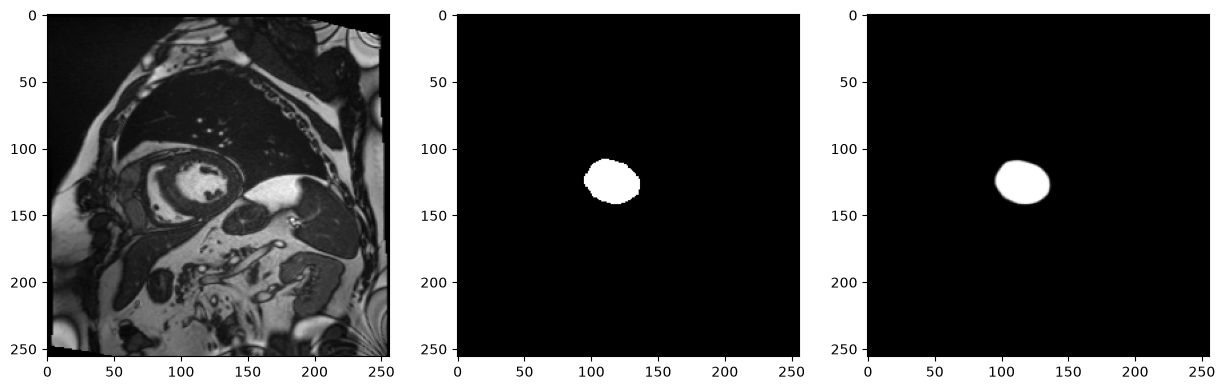

Evaluation Complete
Mean Error: 1.29 ± 4.05 pixels
Min Error:  0.02 pixels
Max Error:  99.93 pixels
----------------------------------------


In [181]:
show_segmentation(model, ds_test, im_number=20)
mean_error, min_error, max_error, std_error = evaluate_fcn1(model, dl_test)
print("Evaluation Complete")
print(f"Mean Error: {mean_error:.2f} ± {std_error:.2f} pixels")
print(f"Min Error:  {min_error:.2f} pixels")
print(f"Max Error:  {max_error:.2f} pixels")
print("-" * 40)

### 4.2. Model evaluation FCN2


#### Define Dataset - testing...??


In [290]:
# TODO: delete
test_image_paths = [file for file in img_paths if "testing" in file]
ds_test_fcn2 = FCN2Dataset(test_image_paths, resized)
dl_test_fcn2 = DataLoader(ds_test_fcn2, **dataloader_args, shuffle=False)

#### Define functions for evaluation:

- Show segmentation


In [ ]:
# TODO:
def show_segmentation_fcn2(model, dataset, im_number=0):
    img, mask = dataset[im_number]
    img = img.to(device)
    mask = mask.to(device)

    # 2. Preparar Predicción
    with torch.no_grad():
        pred = F.sigmoid(model(img.unsqueeze(0))).squeeze(0).cpu()
        pred = (pred > 0.5).float()  # Binarizar

    # Convert for visualization
    img_vis = img.squeeze(0).cpu().numpy()  # Remove channel dimension
    mask_vis = mask.cpu().numpy()
    pred_vis = pred.numpy()

    # 3. Función auxiliar para convertir (2, 128, 128) a (128, 128, 3)
    def mask_to_rgb(m):
        # m es (2, 128, 128). Creamos un lienzo RGB (128, 128, 3)
        h, w = m.shape[1], m.shape[2]
        rgb = np.zeros((h, w, 3))
        rgb[..., 0] = m[0]  # Channel 0 -> Red
        rgb[..., 1] = m[1]  # Channel 1 -> Green
        return rgb

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Original
    axs[0].imshow(img_vis, cmap="gray")
    axs[0].set_title("Original")

    # Ground Truth
    axs[1].imshow(img_vis, cmap="gray")
    axs[1].imshow(mask_to_rgb(mask_vis), alpha=0.5)
    axs[1].set_title("Ground Truth (Red: Cavity, Green: Mio)")

    # Prediction
    axs[2].imshow(img_vis, cmap="gray")
    axs[2].imshow(mask_to_rgb(pred_vis), alpha=0.5)
    axs[2].set_title("Prediction")

    plt.show()

In [ ]:
def calculate_dice_score(pred_binary, target_binary, smooth=1e-6):
    """
    Calcula la métrica Dice Score (Coeficiente de Dice) para evaluación geométrica.
    Fórmula matemática: DSC = (2 * |A ∩ B| + ε) / (|A| + |B| + ε)
    """
    # Aplanar las dimensiones espaciales, manteniendo la dimensión del lote
    pred = pred_binary.view(pred_binary.size(0), -1)
    target = target_binary.view(target_binary.size(0), -1)

    # |A ∩ B|: Producto elemento a elemento y suma espacial
    intersection = (pred * target).sum(dim=1)

    # |A| + |B|: Suma de áreas individuales
    union = pred.sum(dim=1) + target.sum(dim=1)

    # Cálculo del coeficiente de Dice por cada imagen en el lote
    dice = (2.0 * intersection + smooth) / (union + smooth)

    # Extraer el promedio del lote como un escalar estándar de Python
    return dice.mean().item()


def evaluate_fcn2(model, test_loader):
    """
    Bucle de evaluación del modelo sobre el conjunto de prueba.
    """
    model.eval()

    total_dice = 0.0
    num_batches = 0

    with torch.no_grad():
        for img_batch, mask_batch in test_loader:
            img_batch = img_batch.to(device)
            mask_batch = mask_batch.to(device)

            # 1. Inferencia (Logits)
            logits = model(img_batch)

            # 2. Binarización estricta (Umbralización de probabilidad > 0.5)
            # Esto define la frontera final geométrica para la evaluación
            pred_binary = (torch.sigmoid(logits) > 0.5).float()

            # 3. Evaluación de la métrica
            batch_dice = calculate_dice_score(pred_binary, mask_batch)

            total_dice += batch_dice
            num_batches += 1

    # Promedio total del rendimiento geométrico (DSC ∈ [0, 1])
    avg_dice = total_dice / num_batches

    return avg_dice


avg_dice = evaluate_fcn2(model, dl_test_fcn2)


0.9030070446155689


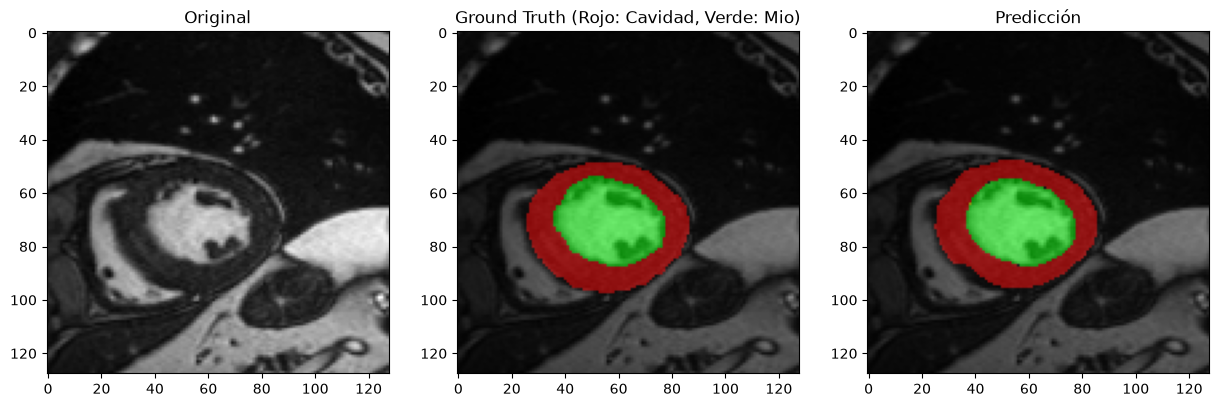

In [ ]:
show_segmentation_fcn2(model, ds_test_fcn2, im_number=20)
print(avg_dice)